# Patch Reassembly Environment Demo

This notebook demonstrates the Patch Reassembly environment where you place patches to reconstruct an image.

In [1]:
import gymnasium as gym
import numpy as np
from IPython.display import display
from PIL import Image

## 1. Create and Inspect Environment (Easy - 6x6 grid)

In [2]:
env = gym.make("patch_reassembly/easy", seed=42)
print(f"Grid size: {env.unwrapped.grid_size}")
print(f"Number of patches: {env.unwrapped.num_patches}")
print(f"Action Space: {env.action_space}")
print(f"Available actions: {env.action_space.get_function_names()}")

Grid size: (6, 6)
Number of patches: 5
Action Space: FuncConditional(['place', 'remove', 'stop'])
Available actions: ['place', 'remove', 'stop']


## 2. Reset and View Initial State

Observation shape: (800, 560, 3)
Info: {'proportion_filled': np.float64(0.0), 'current_state': [(np.int64(-3), np.int64(0)), (np.int64(0), np.int64(7)), (np.int64(7), np.int64(0)), (np.int64(0), np.int64(-3)), (np.int64(-5), np.int64(4))], 'env_feedback': None}


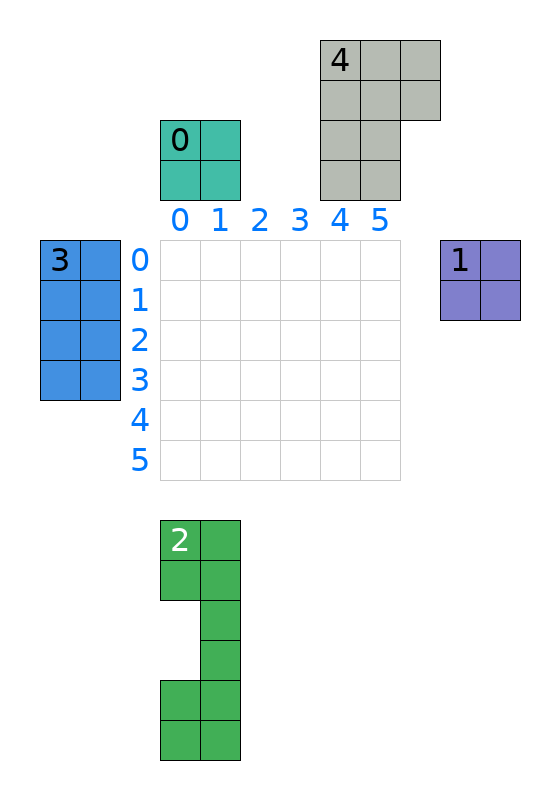


Task: Place patches to reconstruct the original image

Task Prompt:
You are solving a 6×6 patch-reassembly puzzle. There are 5 irregular pieces parked around the board. Your goal is to place them so the grid is completely filled—no gaps, no overlaps.
You see an image of the board and the parked patches.

Available actions:
1. 'place': Snap a patch onto the grid by aligning its anchor (the cell that shows the patch's ID number) with a chosen board coordinate. Format: `('place', (patch_id, row, col))` where patch_id ∈ [0, 4], row ∈ [0, 5], col ∈ [0, 5].
2. 'remove': Return a patch to its parking slot. Format: `('remove', patch_id)` where patch_id ∈ [0, 4].
3. 'stop': End the episode and submit your solution. Format: `('stop', 'stop')`

Success: You succeed if the grid is completely filled with no gaps or overlaps.

Please respond with exactly one action and its arguments in the specified format. For example:
- To place patch 0 at (2, 3): `('place', (0, 2, 3))`
- To remove patch 0: `('re

In [3]:
obs, info = env.reset()
print(f"Observation shape: {obs.shape}")
print(f"Info: {info}")

display(Image.fromarray(obs))
print(f"\nTask: Place patches to reconstruct the original image")
print(f"\nTask Prompt:\n{env.get_prompt()}")

## 3. Test Manual Actions

In [4]:
# Place a patch
action = "('place', (0, 2, 3))"
obs, reward, terminated, truncated, info = env.step(action)
print(f"Action: {action}")
print(f"Proportion filled: {info.get('proportion_filled', 0):.2%}")
display(Image.fromarray(obs))

Testing manual actions...
Note: Action format depends on environment implementation


## 4. Test Solver

Initial state:


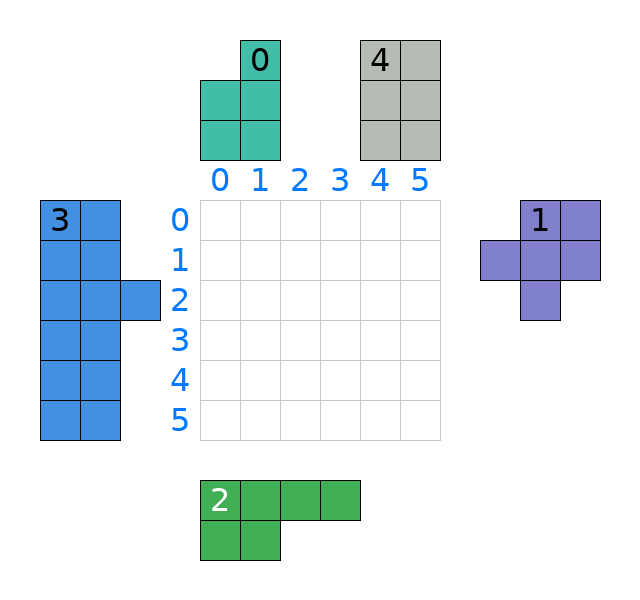


Solver generated 6 actions

Step 1: ('place', (0, 3, 5))


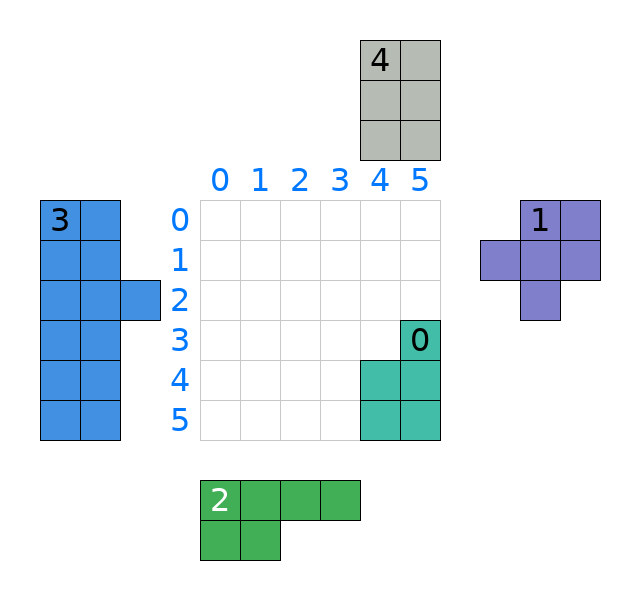


Step 2: ('place', (1, 1, 4))


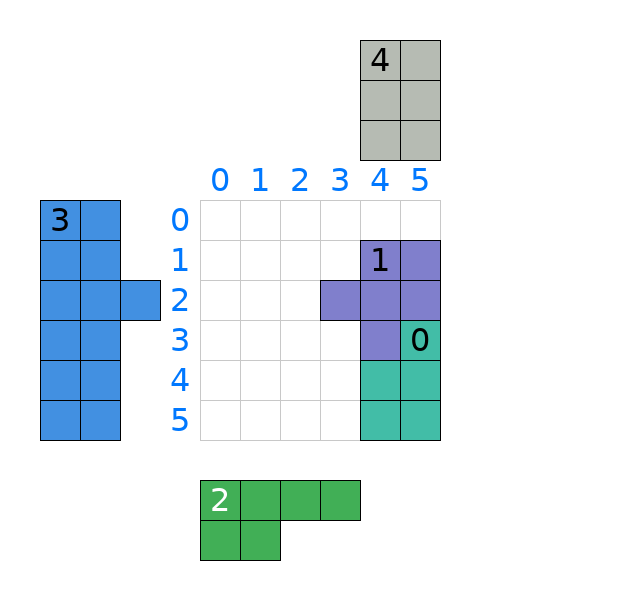


Step 3: ('place', (2, 0, 2))


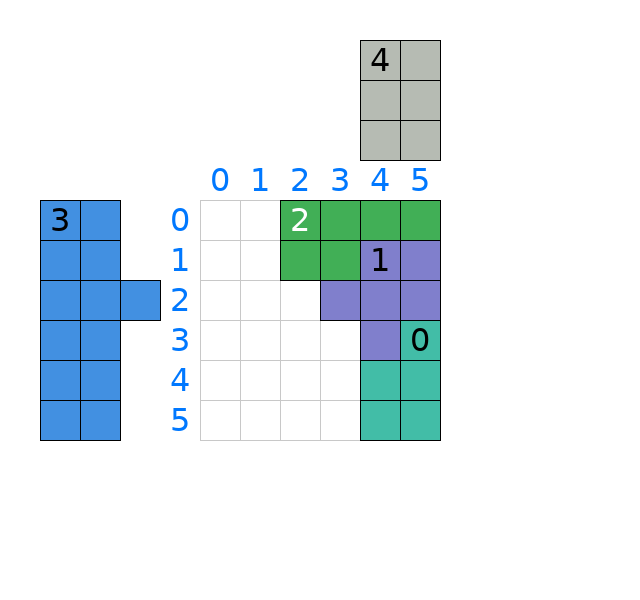


Step 6: ('stop', 'stop')


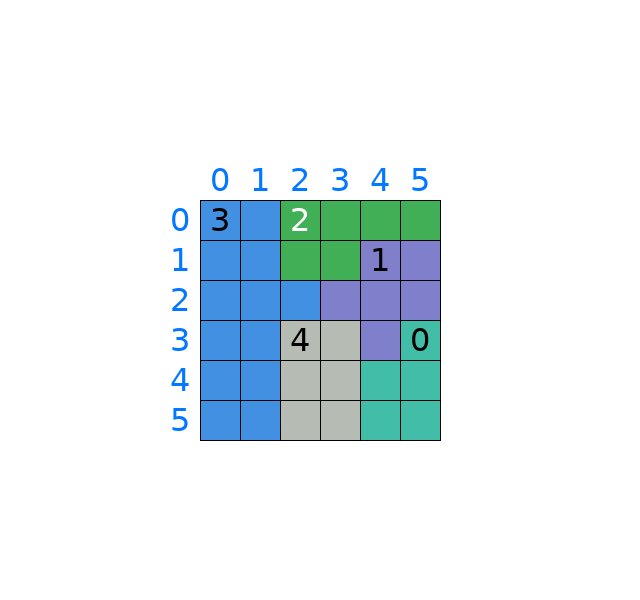


✓ Image reassembled! Reward: 1.0


In [5]:
env = gym.make("patch_reassembly/easy", seed=100)
obs, info = env.reset()
print("Initial state:")
display(Image.fromarray(obs))

# Get solver actions
actions = env.solve()
print(f"\nSolver generated {len(actions)} actions")

# Execute solver actions
for i, action in enumerate(actions):
    obs, reward, terminated, truncated, info = env.step(action)
    if i < 3 or terminated:  # Show first 3 and final
        print(f"\nStep {i+1}: {action}")
        display(Image.fromarray(obs))
    if terminated:
        print(f"\n✓ Image reassembled! Reward: {reward}")
        break

env.close()

## 5. Test Hard Difficulty (8x8 grid, more patches)

Hard difficulty - grid: (8, 8), patches: 6
(vs easy - grid: (6, 6), patches: 5)


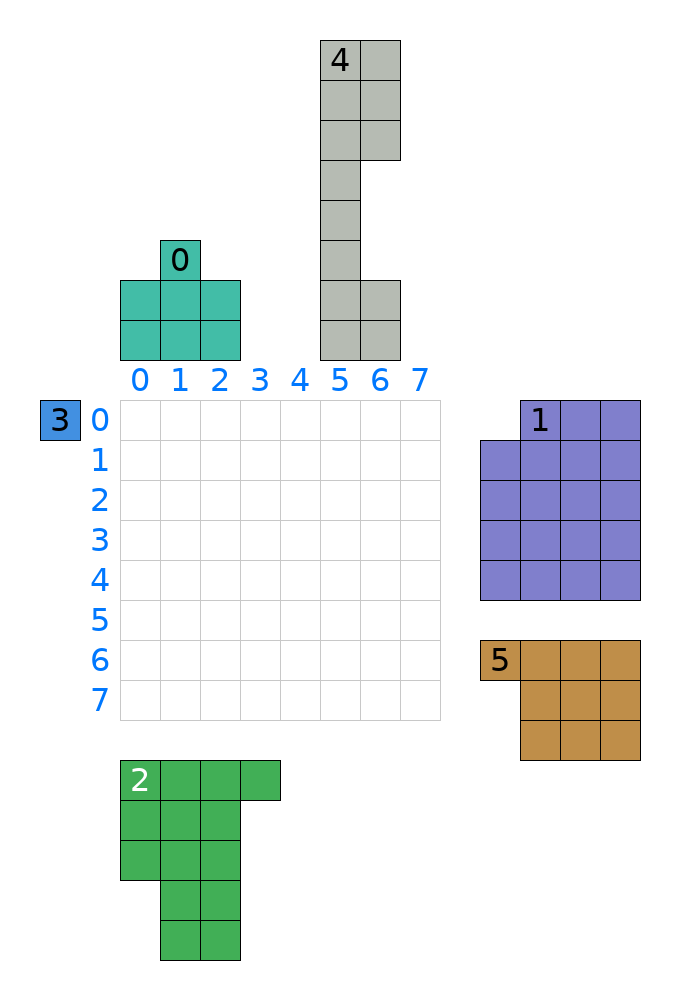


Solution: 7 actions
Action: ('place', (0, 0, 3))


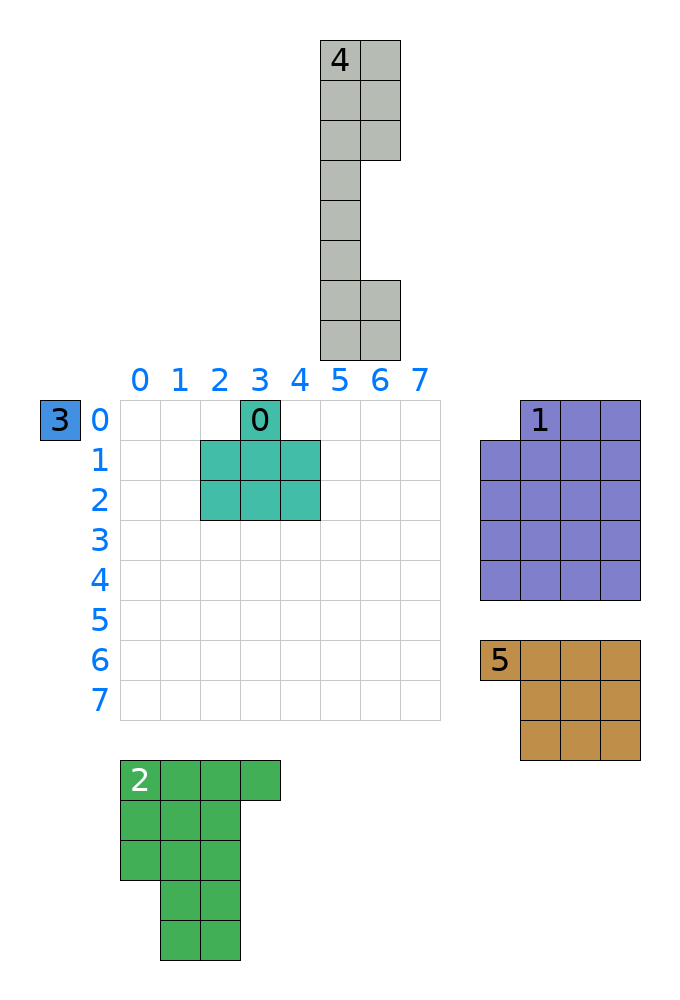

Action: ('place', (1, 3, 5))


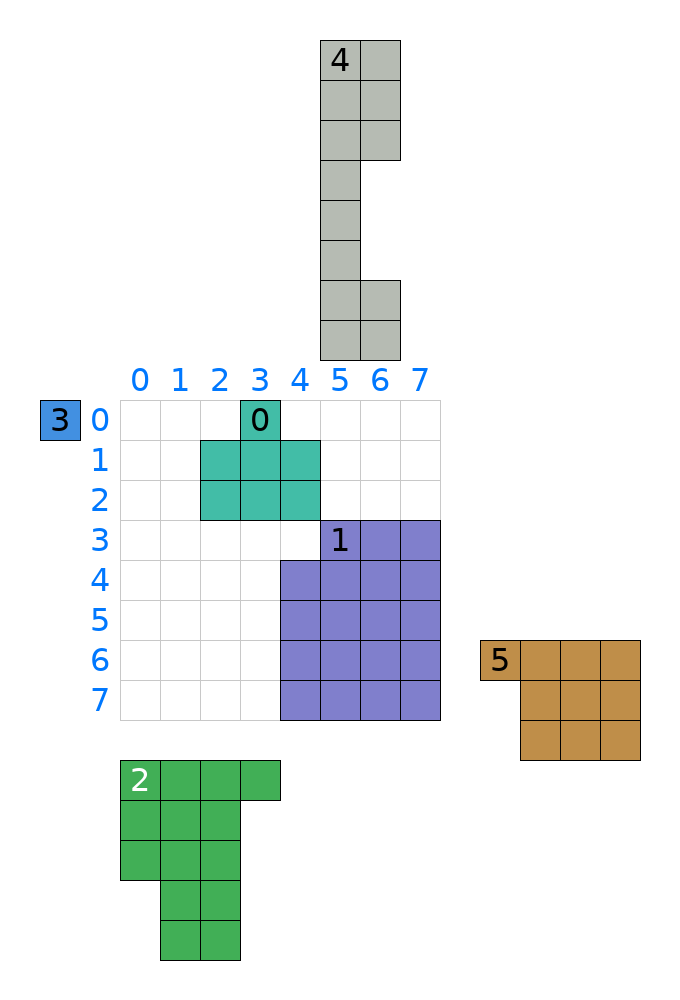

Action: ('place', (2, 3, 1))


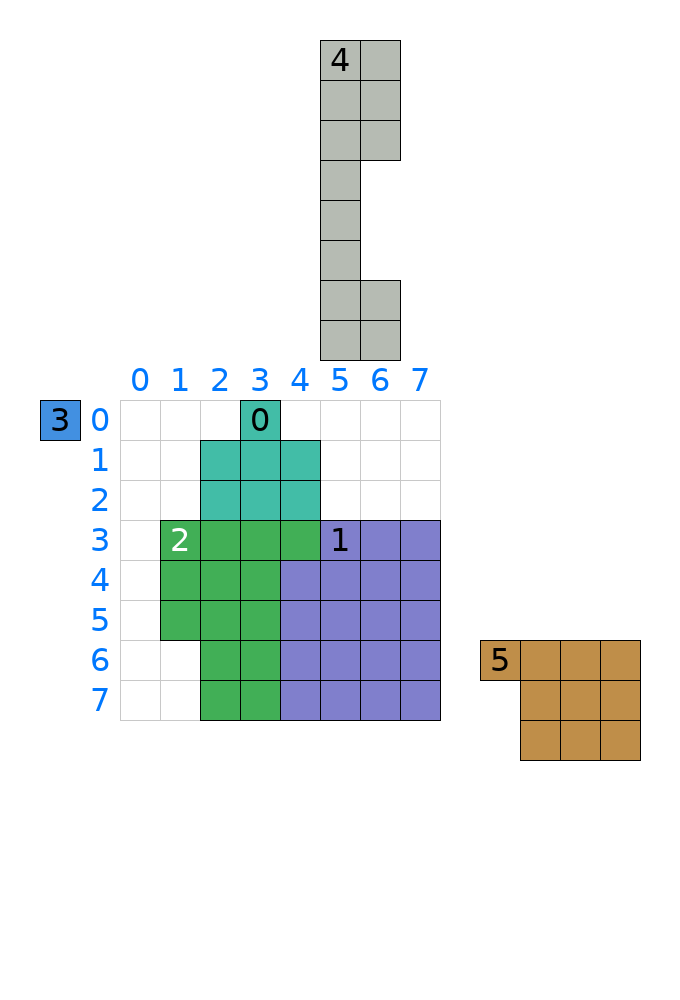

Action: ('place', (3, 0, 2))


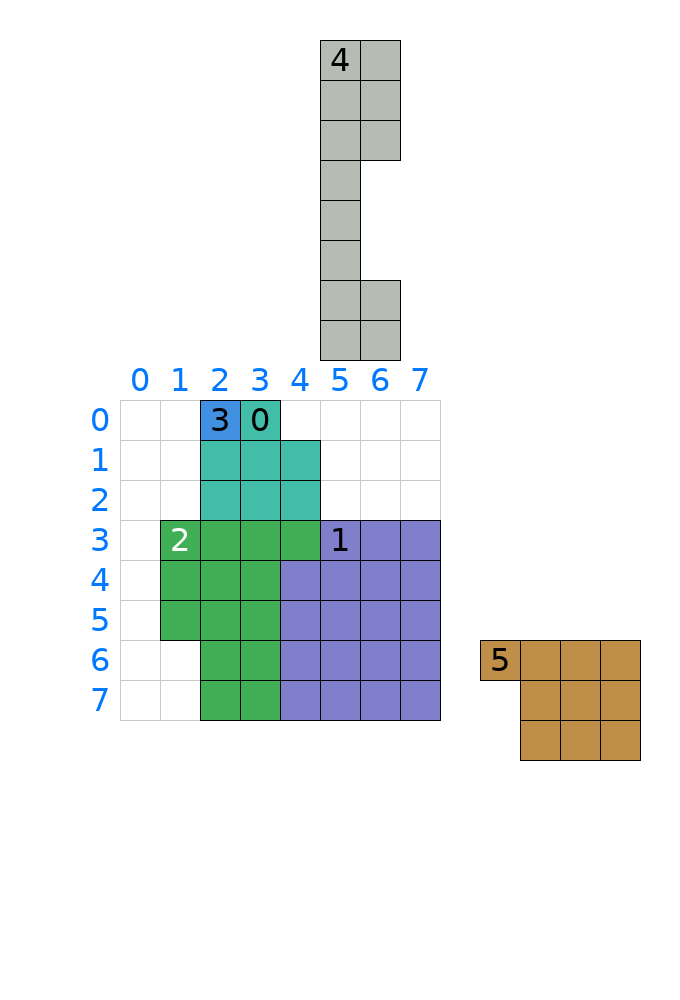

Action: ('place', (4, 0, 0))


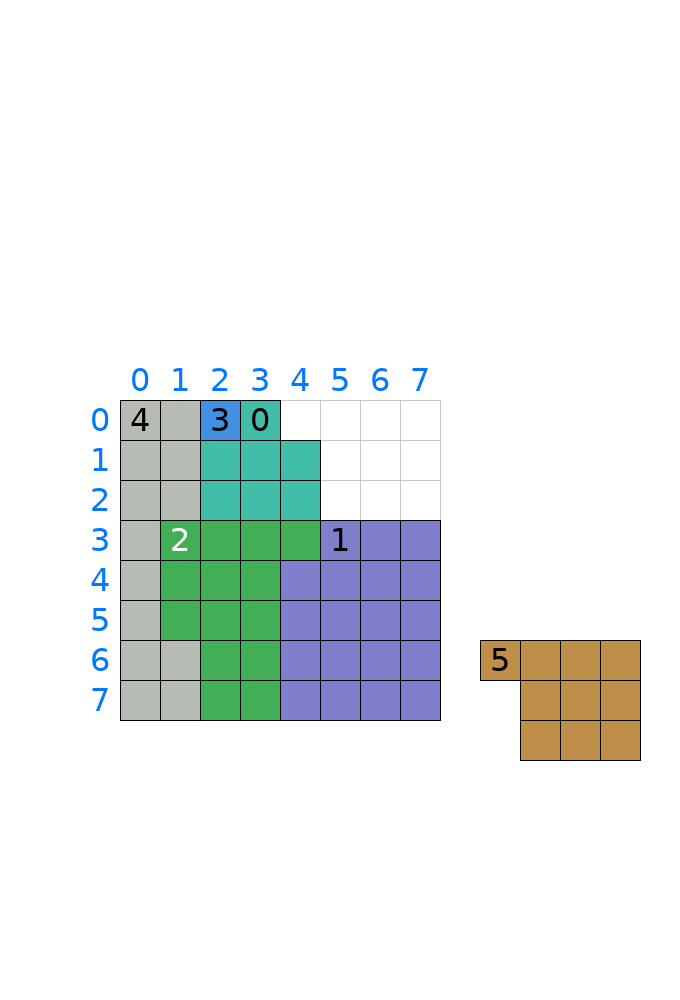

Action: ('place', (5, 0, 4))


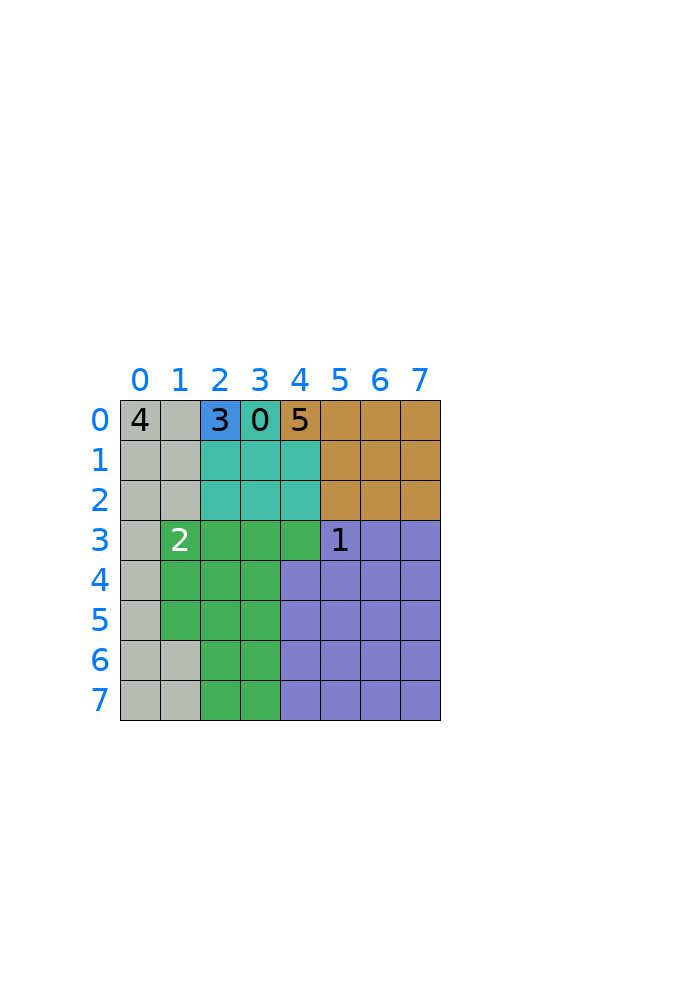

Action: ('stop', 'stop')


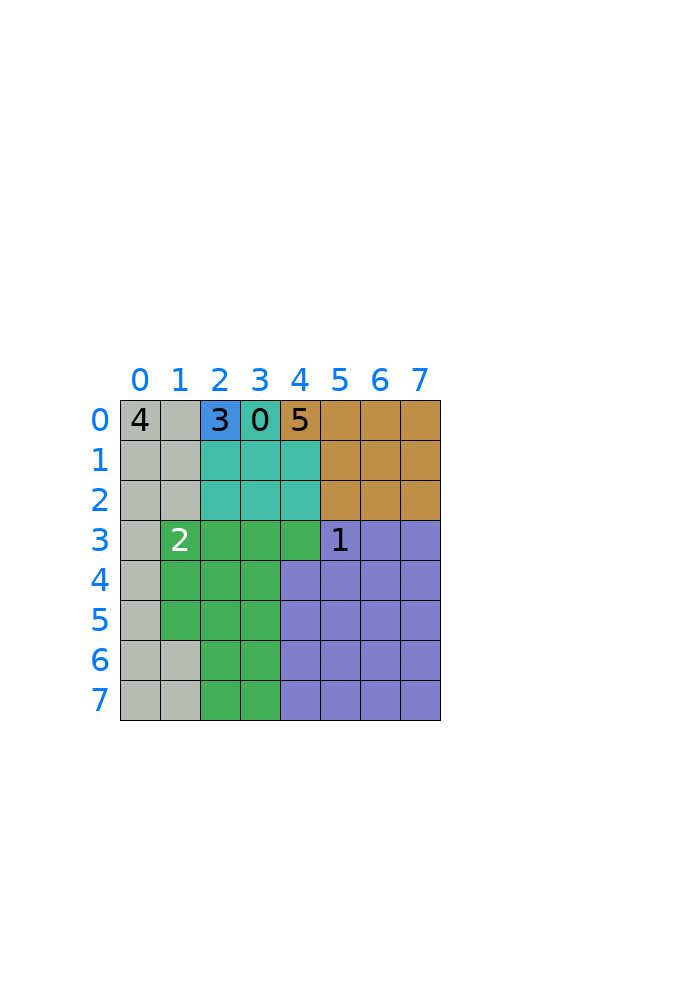

Reward: 1.0


In [8]:
env_hard = gym.make("patch_reassembly/hard", seed=42)
obs, info = env_hard.reset()
print(f"Hard difficulty - grid: {env_hard.unwrapped.grid_size}, patches: {env_hard.unwrapped.num_patches}")
print(f"(vs easy - grid: (6, 6), patches: 5)")
display(Image.fromarray(obs))

# Get solution
actions = env_hard.solve()
print(f"\nSolution: {len(actions)} actions")
for action in actions:
    obs, reward, terminated, truncated, info = env_hard.step(action)
    print(f"Action: {action}")
    display(Image.fromarray(obs))
    if terminated:
        print(f"Reward: {reward}")
        break

env_hard.close()